In [1]:
# PCA:

In [ ]:
# Task 1: Exploratory Data Analysis (EDA):
# 1. Load the dataset and perform basic data exploration.

In [2]:
# Load the Dataset 
import pandas as pd 
df = pd.read_csv("wine.csv")

In [3]:
# Head of the Dataset 
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
# Tail of the Dataset 
df.tail()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840
177,3,14.13,4.10,2.74,24.5,96,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560


In [5]:
# Shape of Dataset 
df.shape 

(178, 14)

In [6]:
# Columns of Dataset 
df.columns

Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

In [7]:
# General Information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [8]:
# Statistical Summary 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Type,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoids,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


In [9]:
# Check the Missing Values 
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [10]:
# Check Duplicate Values 
df.duplicated().sum()

np.int64(0)

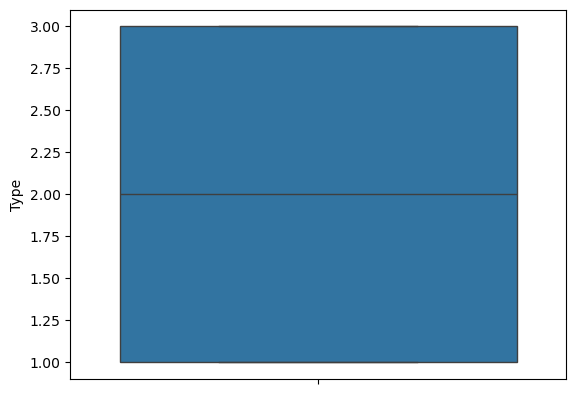

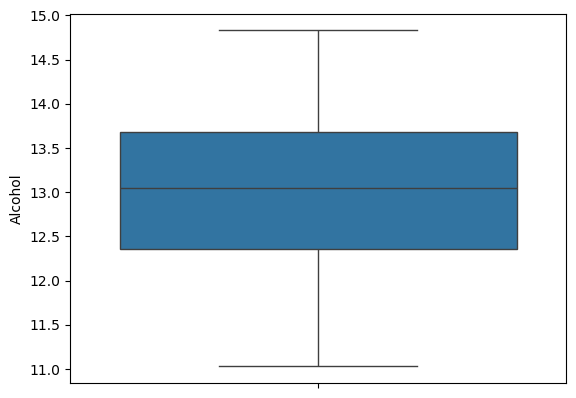

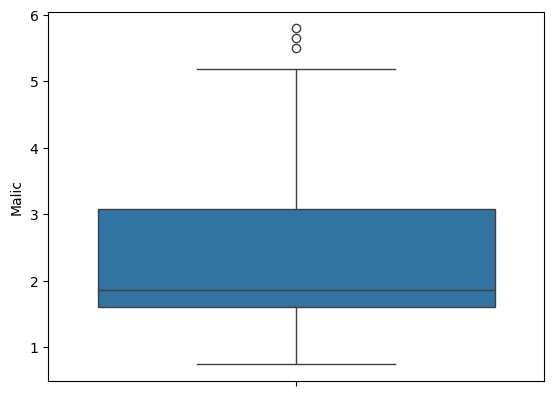

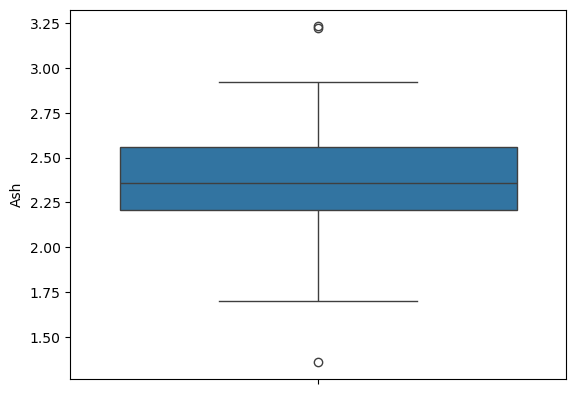

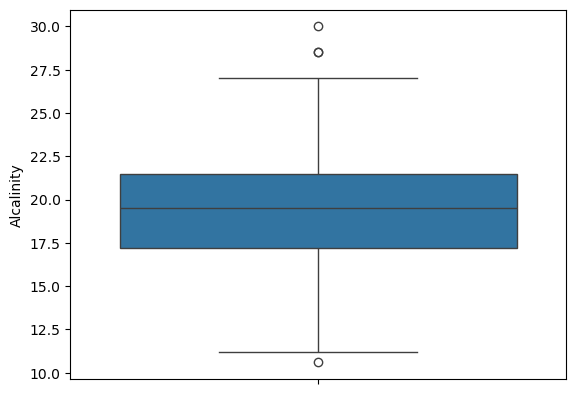

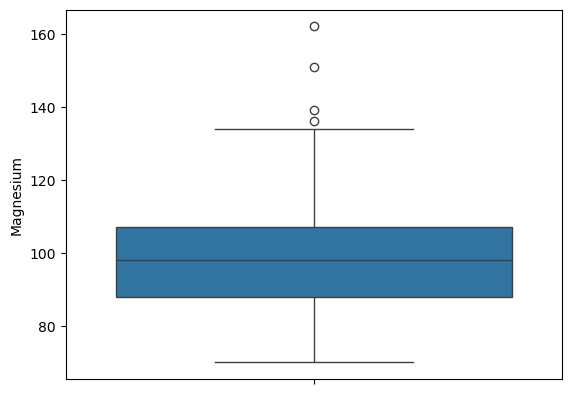

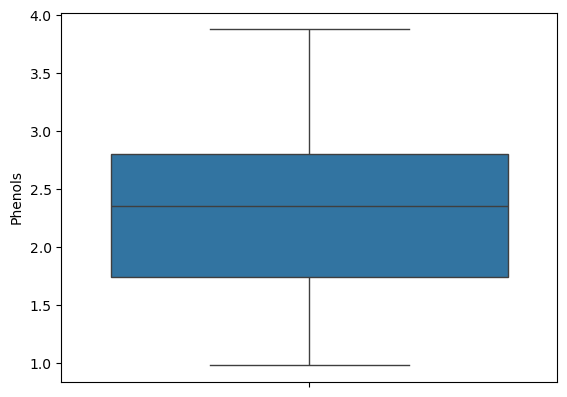

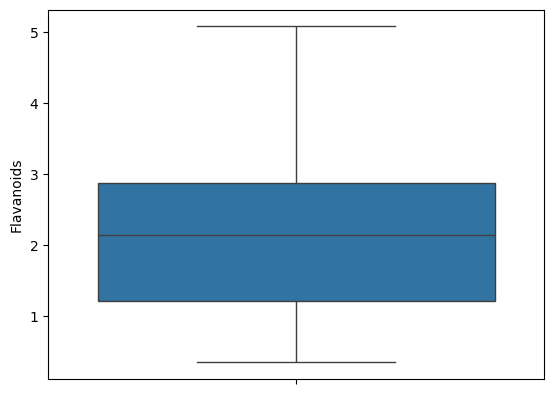

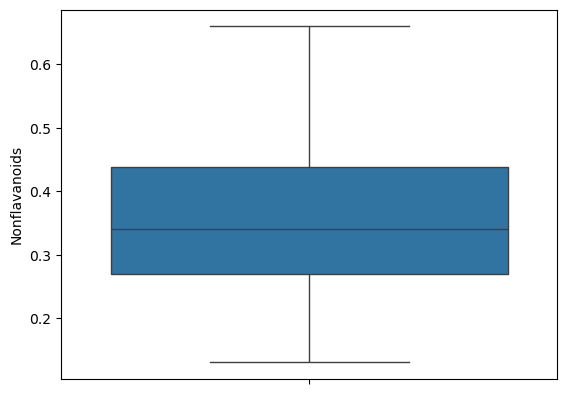

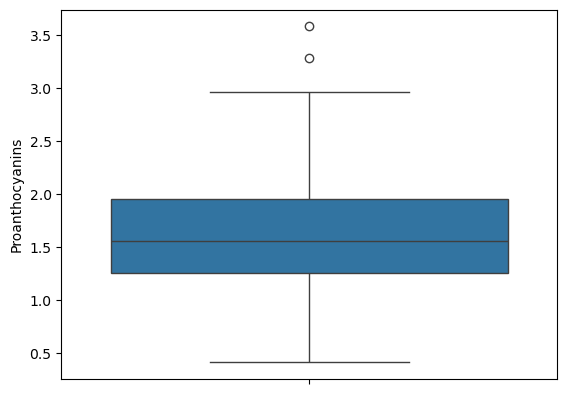

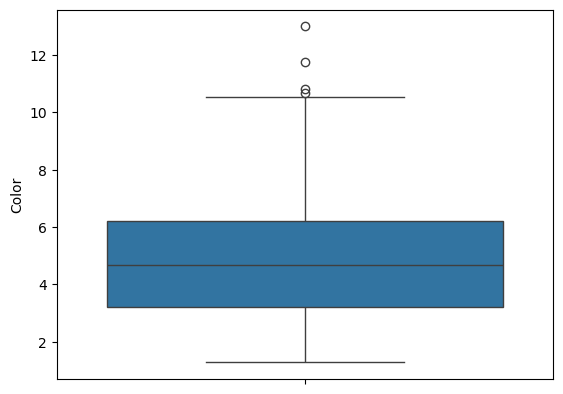

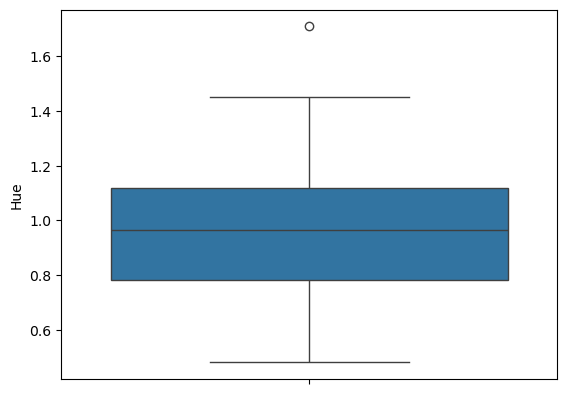

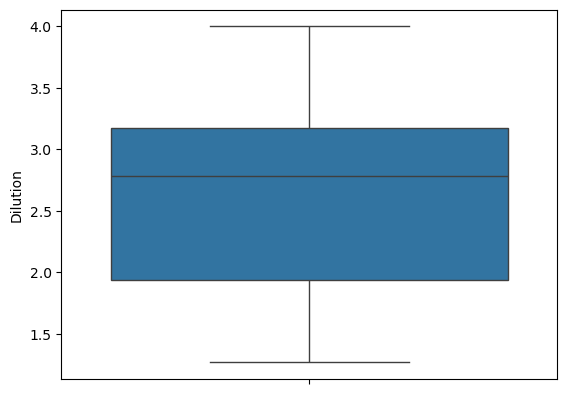

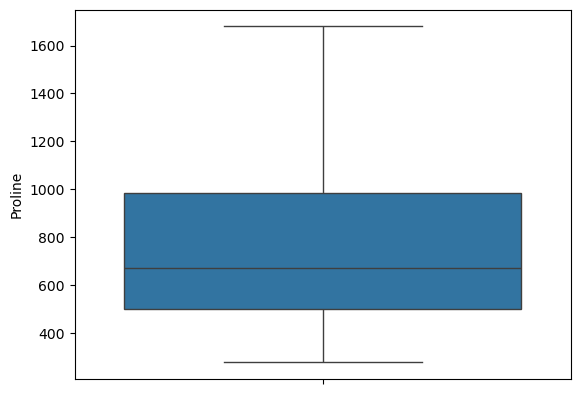

In [11]:
# Check Oitlier 
import matplotlib.pyplot as plt 
import seaborn as sns 

for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot(df[col])
    plt.show()

In [12]:
# Oitlier Capping 
for i in df.select_dtypes(include = ['int','float']).columns:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)

    IQR  = q1 - q3 
    lower_bound = q1 - 1.5*IQR
    upper_bound = q3 + 1.5*IQR

    df[i] = df[i].clip(lower_bound, upper_bound)

In [13]:
# Verify 
import matplotlib.pyplot as plt 
import seaborn as sns 

# for col in df.select_dtypes(include = ['int','float']).columns:
#     sns.boxplot(df[col])
#     plt.show()

In [14]:
# 2. Examine the distribution of features using histograms, box plots, or density plots.

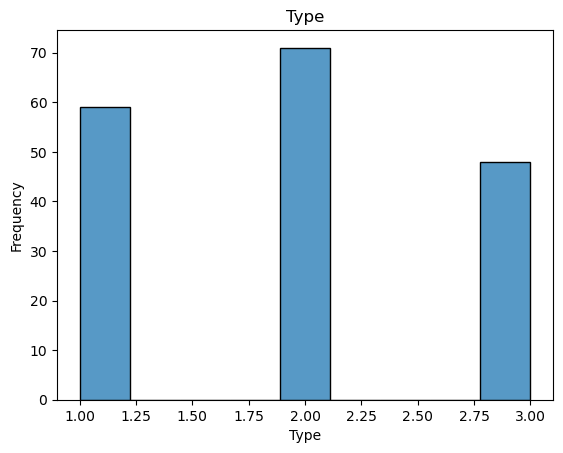

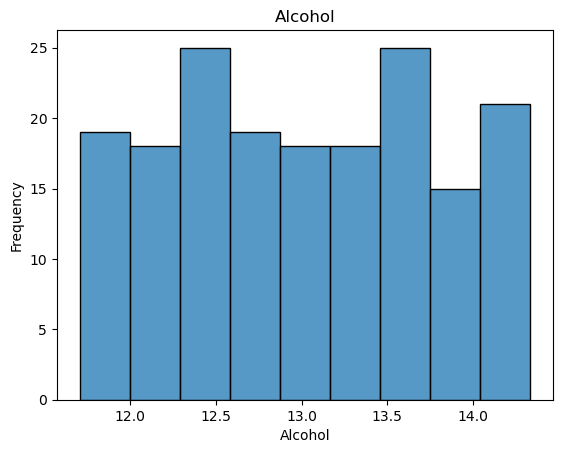

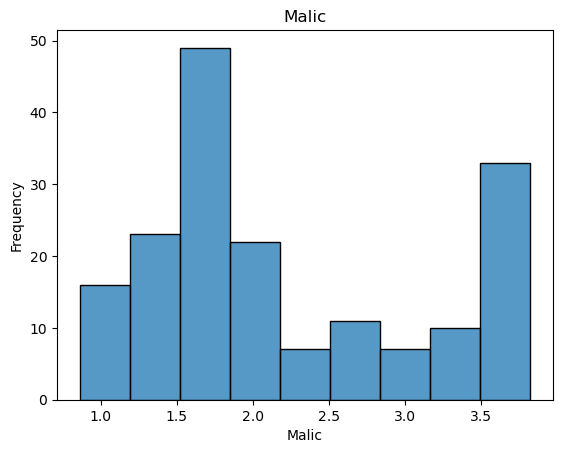

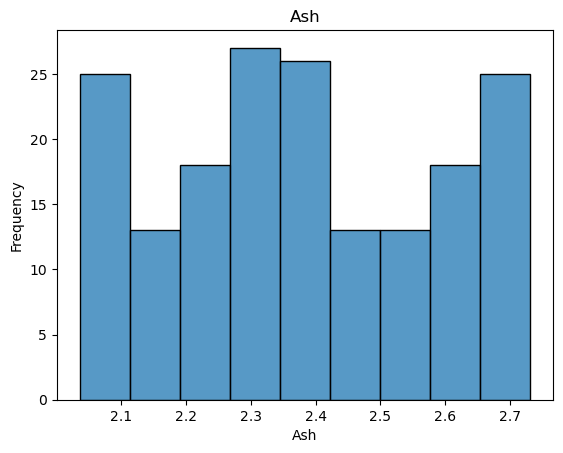

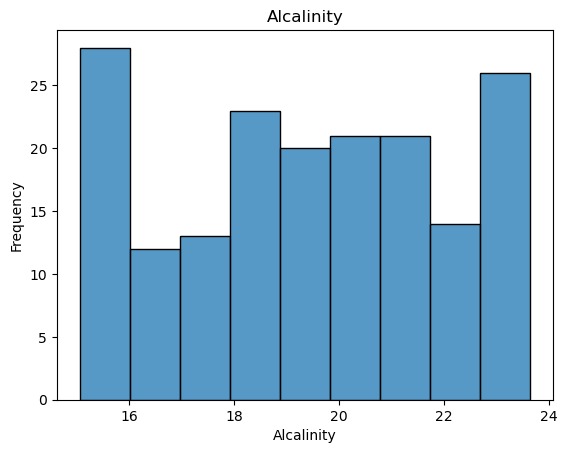

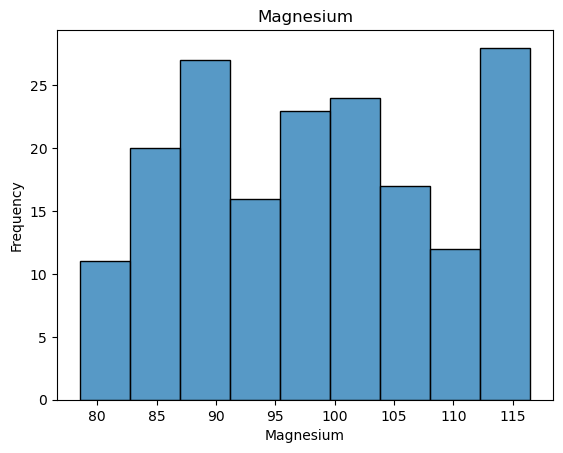

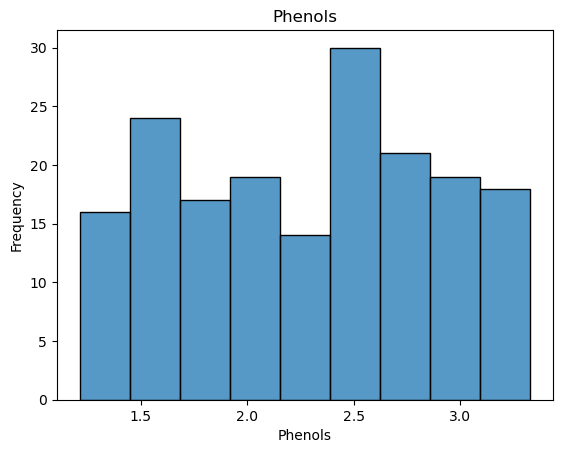

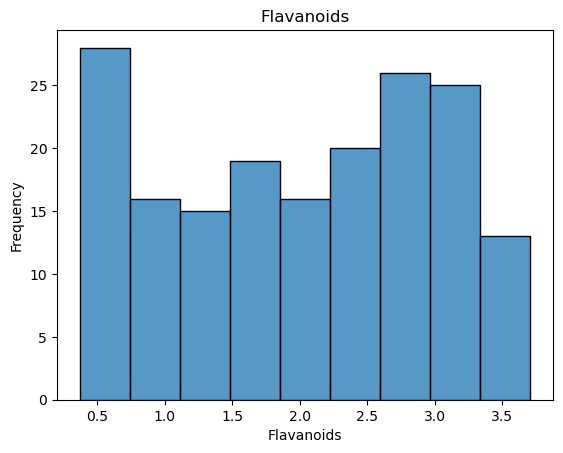

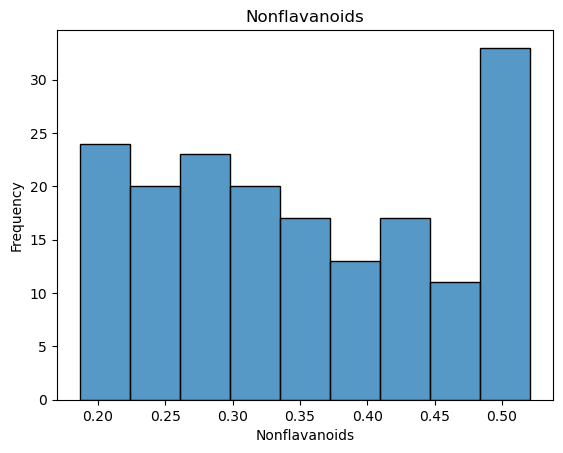

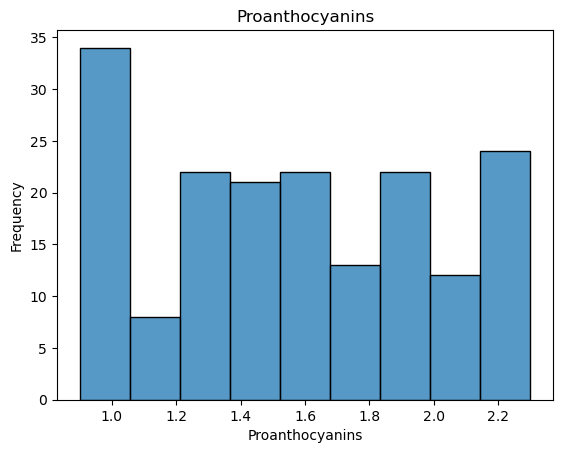

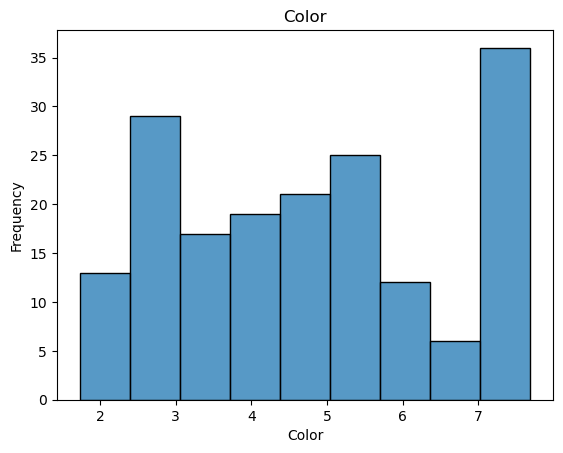

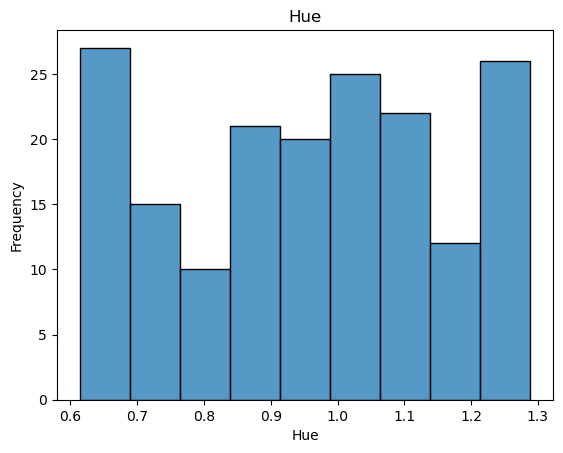

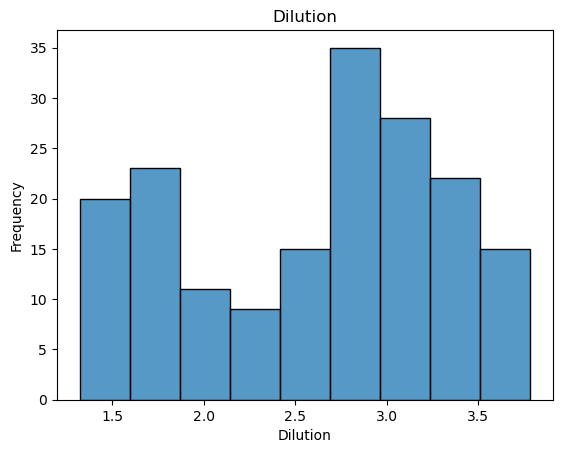

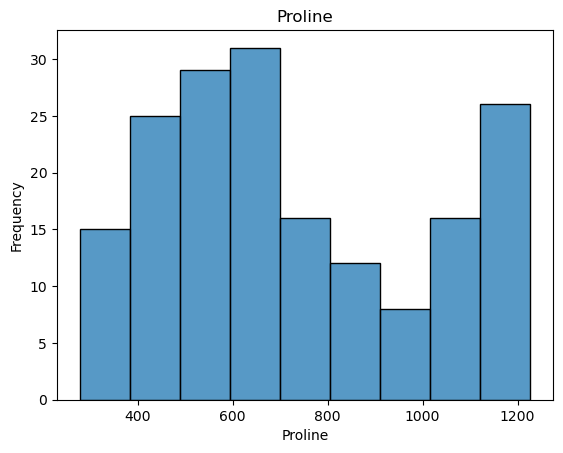

In [15]:
# HIST PLOT 
import matplotlib.pyplot as plt 
import seaborn as sns

for col in df.select_dtypes(include = ['int','float']).columns:
    sns.histplot(df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.show()

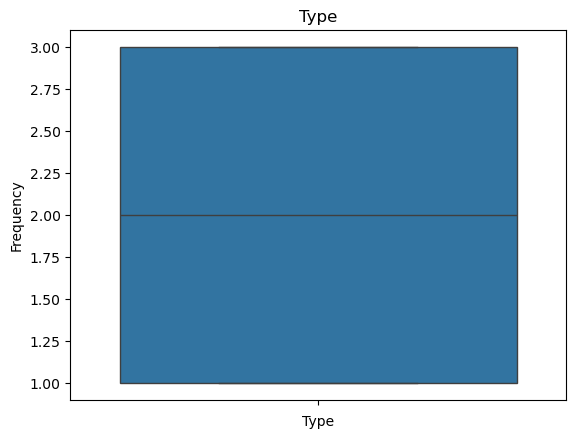

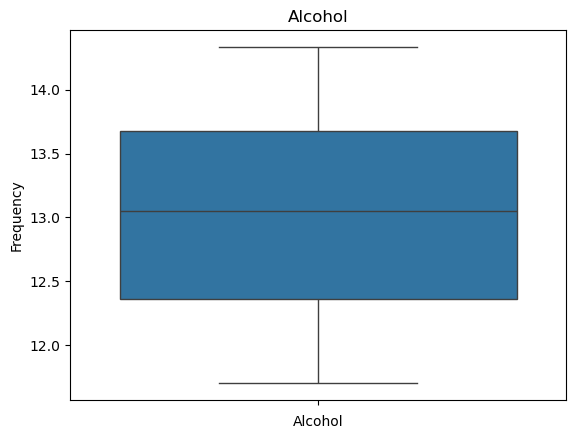

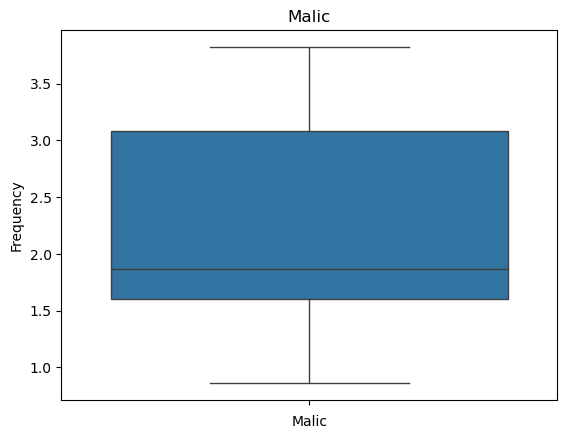

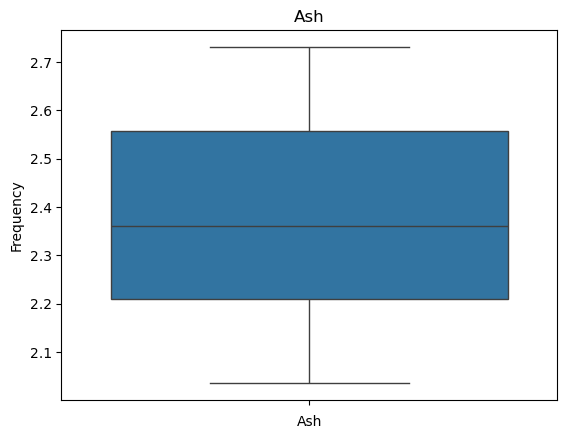

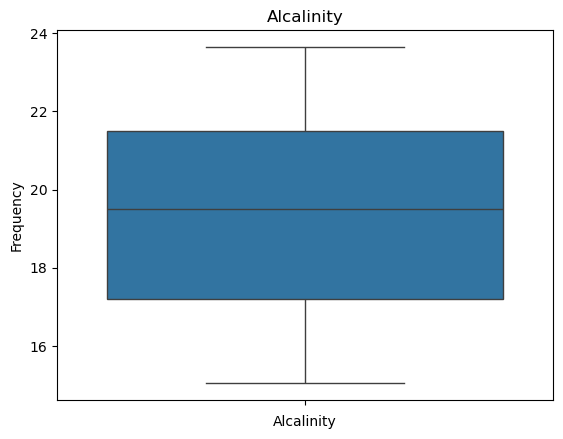

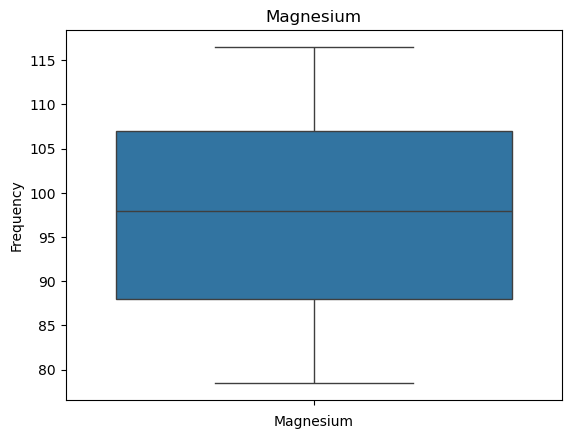

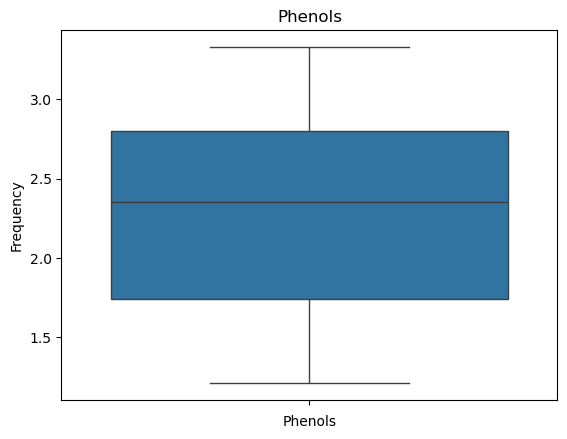

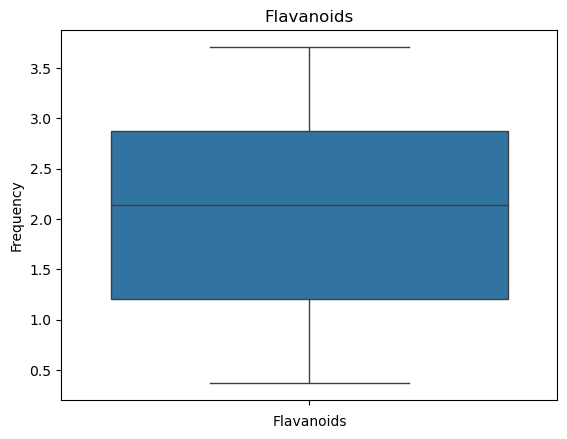

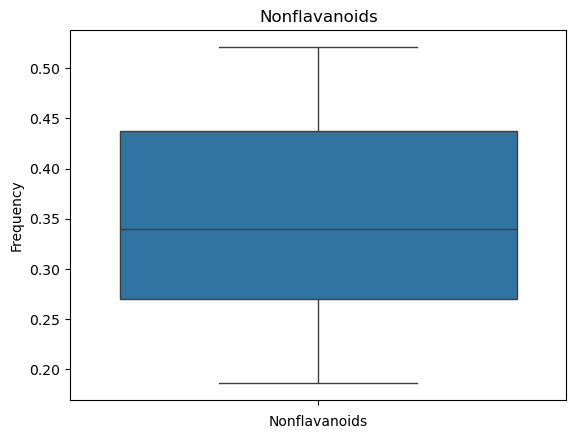

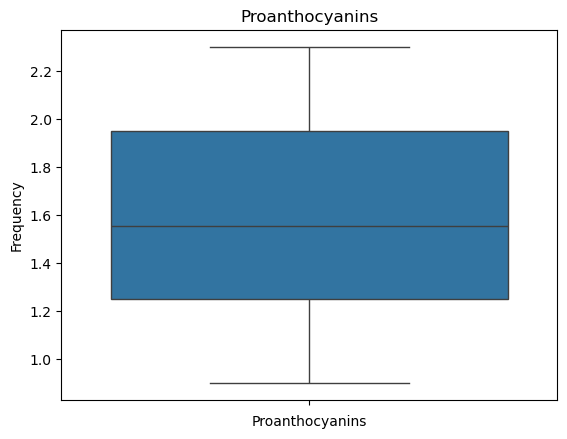

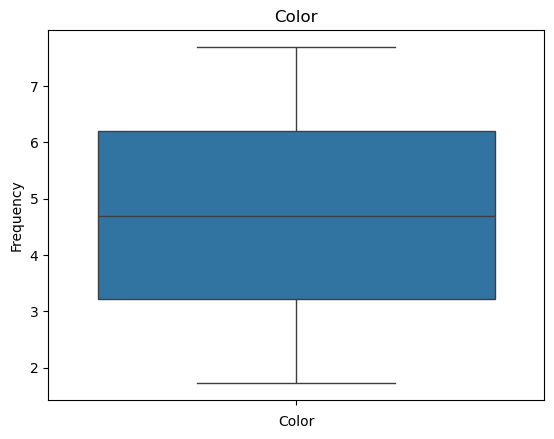

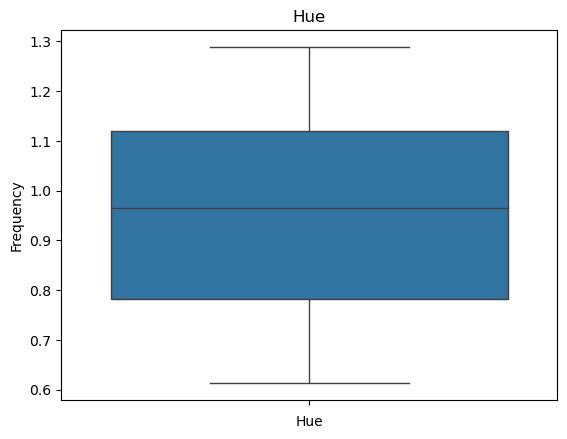

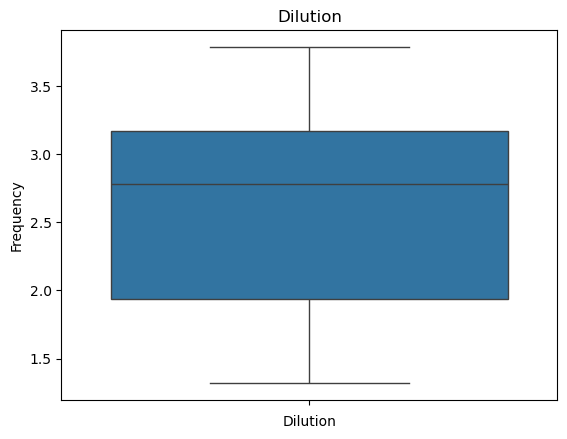

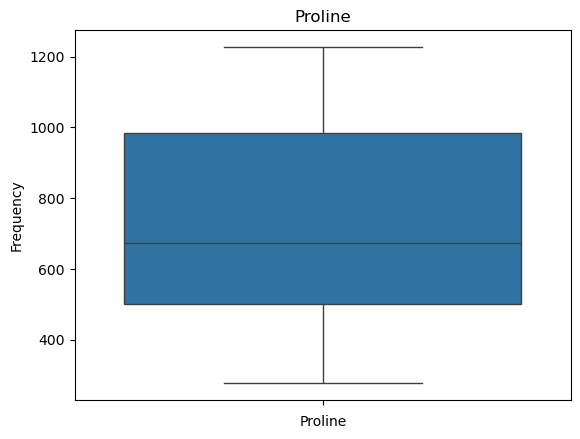

In [16]:
# BOX PLOT 
import matplotlib.pyplot as plt 
import seaborn as sns 

for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.show()

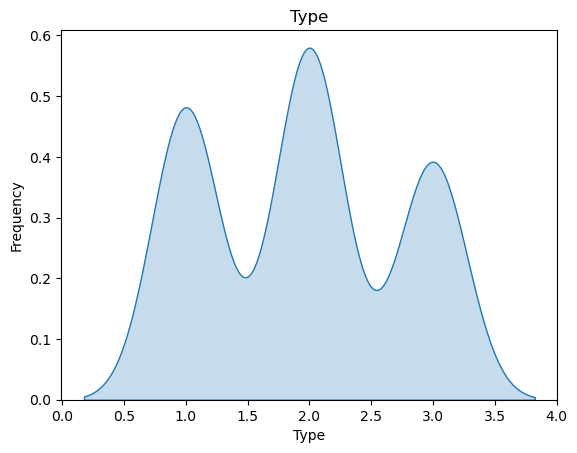

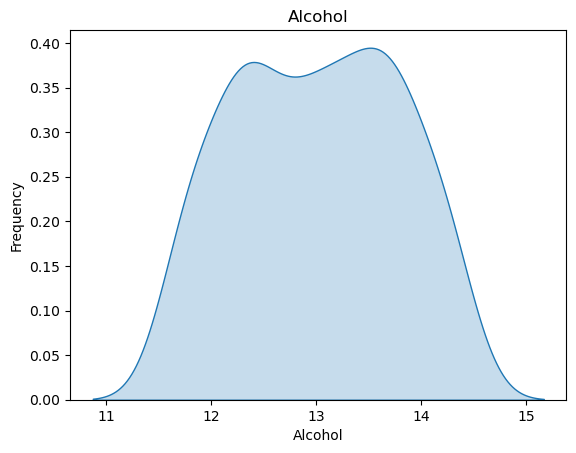

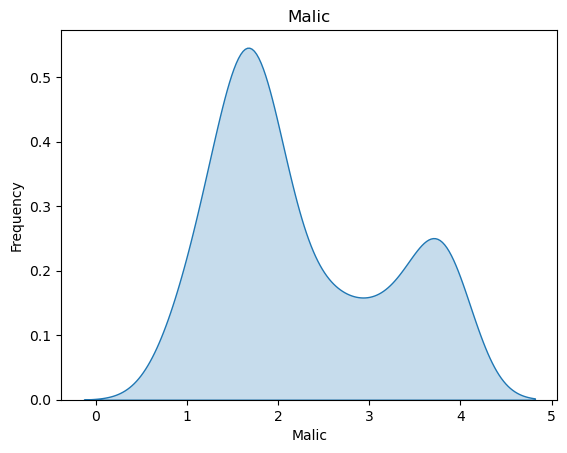

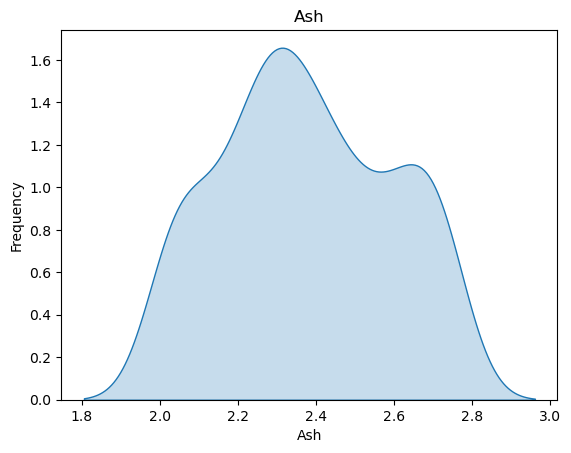

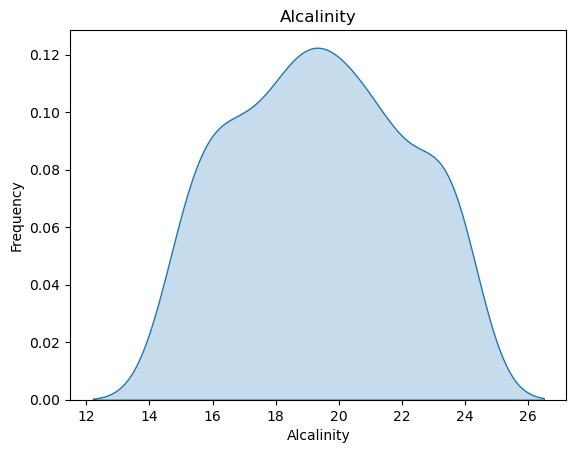

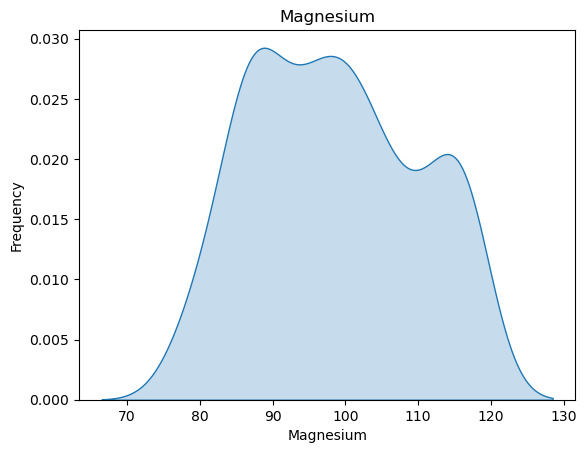

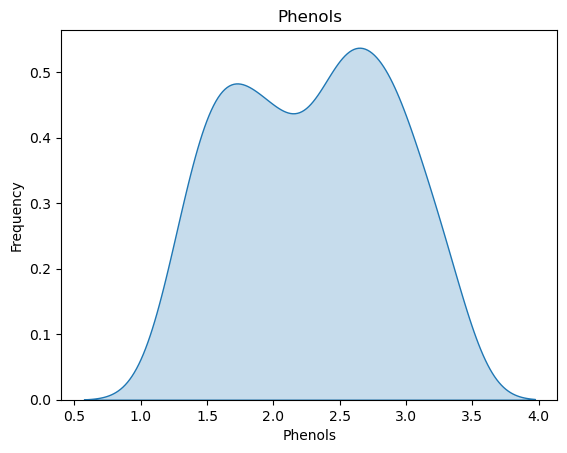

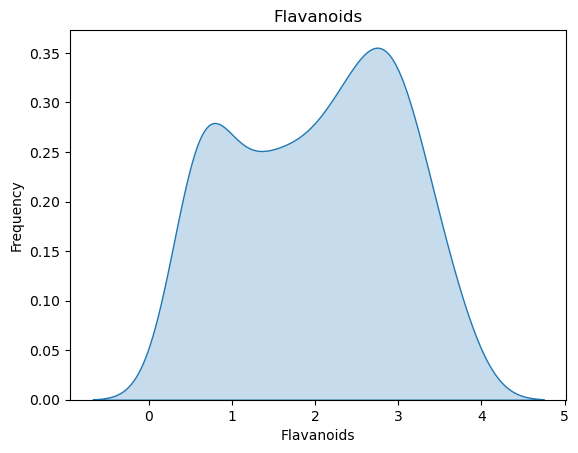

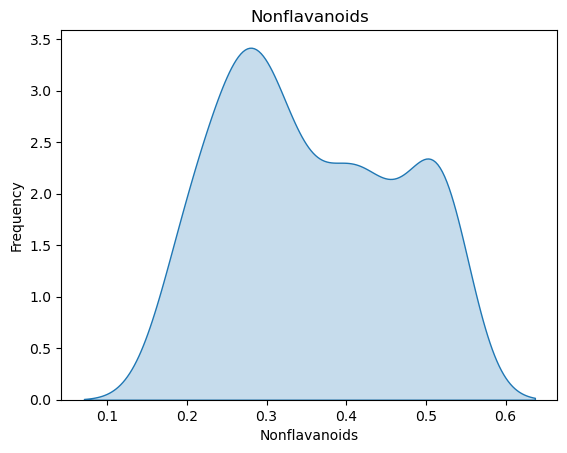

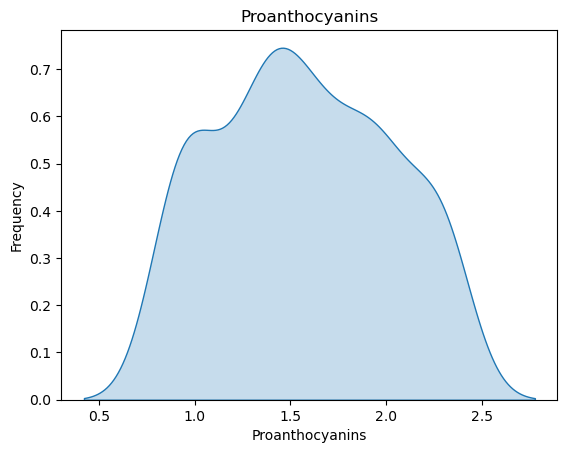

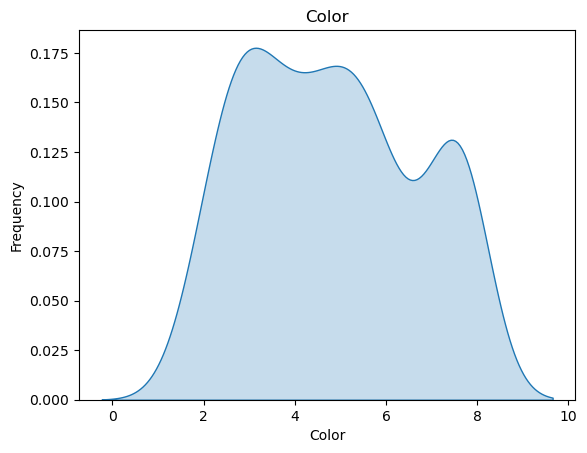

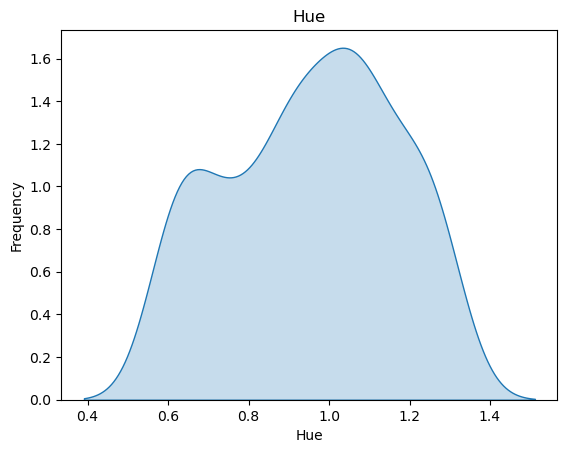

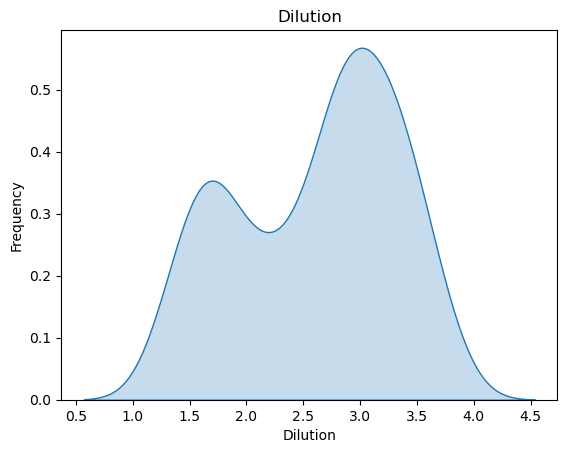

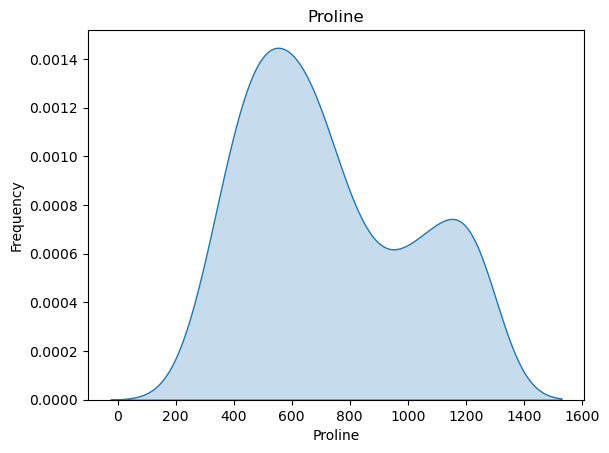

In [17]:
# DENSITY PLOT 
import matplotlib.pyplot as plt 
import seaborn as sns

for col in df.select_dtypes(include = ['int','float']).columns:
    sns.kdeplot(df[col], fill = True)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.show()

In [18]:
# 3. Investigate correlations between features to understand relationships within the data.

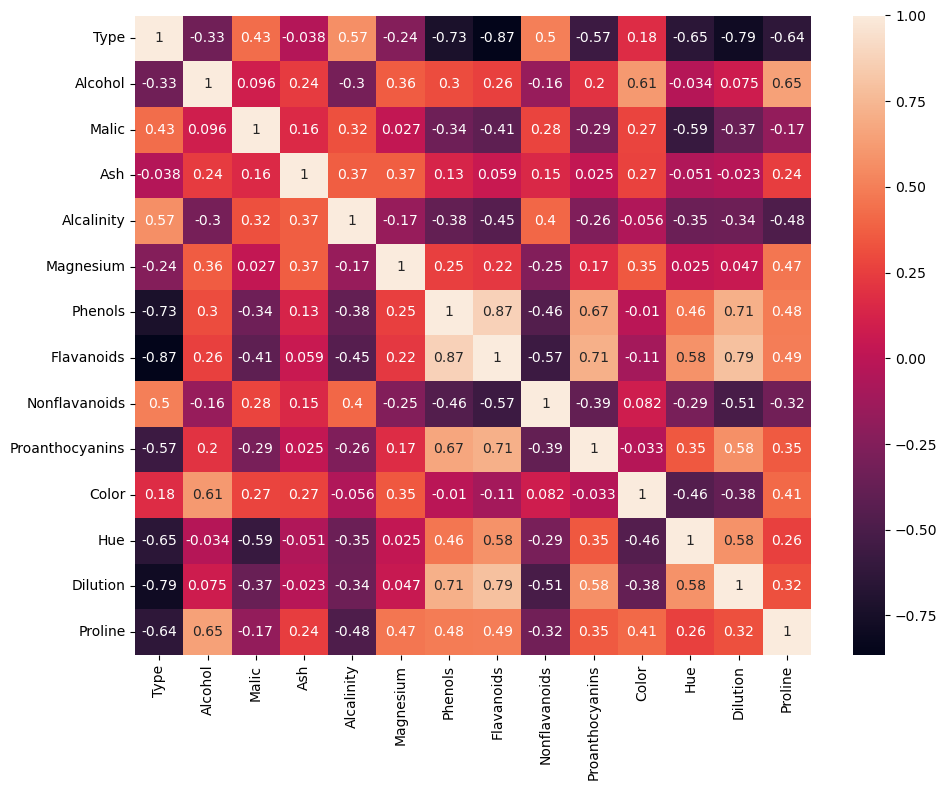

In [19]:
# HEATMAP 
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.figure(figsize = (10,8))
sns.heatmap(df.corr (numeric_only = True), annot = True)
plt.tight_layout()
plt.show()

In [20]:
# Task 2: Dimensionality Reduction with PCA:

# 1. Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.

In [21]:
# Extract Feture and Target
x = df.drop(columns = 'Type')
y = df['Type']
print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (178, 13)
y shape: (178,)


In [22]:
# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [23]:
print("Mean:", x_scaled.mean(axis=0))
print("Standard Deviation:", x_scaled.std(axis=0))

Mean: [-1.99590656e-15 -1.59672525e-16 -3.14355283e-16 -6.78608231e-16
  3.99181312e-17 -1.07778954e-15 -1.19754394e-16 -1.59672525e-16
 -4.79017575e-16 -2.24539488e-17 -2.39508787e-16  4.39099443e-16
  1.19754394e-16]
Standard Deviation: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [24]:
# Apply PCA 
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

x_pca = pca.fit_transform(x_scaled)

print("Original shape:", x.shape)
print("PCA shape:", x_pca.shape)

Original shape: (178, 13)
PCA shape: (178, 2)


In [25]:
# 2. Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.

In [26]:
# Fit PCA with all components
from sklearn.decomposition import PCA

pca = PCA()

x_pca = pca.fit_transform(x_scaled)

In [27]:
# Check Variance 
print(pca.explained_variance_ratio_)

[0.37768039 0.20691059 0.10129462 0.06953381 0.05892623 0.04399588
 0.03753719 0.02588114 0.02186409 0.01896594 0.01776275 0.01244966
 0.00719771]


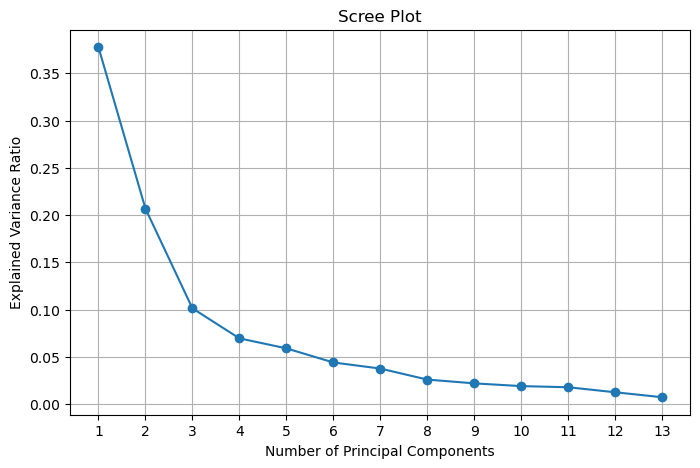

In [28]:
# Scree Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))

plt.grid()
plt.show()

In [29]:
# Cumulative Explained Variance
import numpy as np

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)

[0.37768039 0.58459098 0.6858856  0.75541941 0.81434565 0.85834152
 0.89587871 0.92175985 0.94362394 0.96258988 0.98035262 0.99280229
 1.        ]


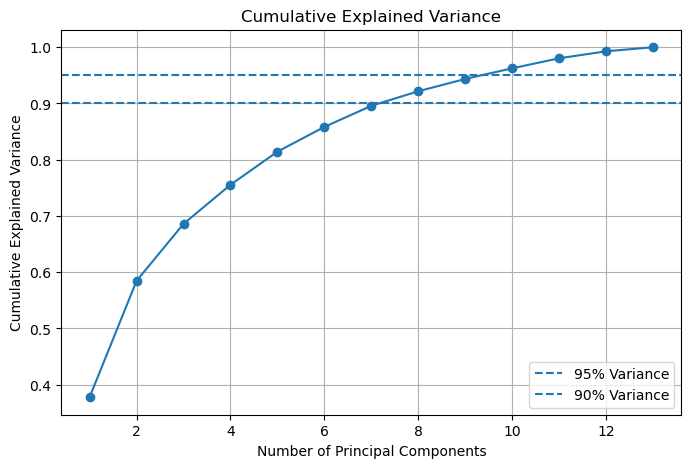

In [30]:
# visualize
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.axhline(
    y=0.95,
    linestyle='--',
    label='95% Variance'
)

plt.axhline(
    y=0.90,
    linestyle='--',
    label='90% Variance'
)

plt.legend()
plt.grid()

plt.show()

In [31]:
# 3.Transform the original dataset into the principal components

In [32]:
import numpy as np
from sklearn.decomposition import PCA

# PCA with all components
pca = PCA()
x_pca = pca.fit_transform(x_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Find number of components required for 95% variance
n_components = np.argmax(
    cumulative_variance >= 0.95
) + 1

print("Optimal number of components:", n_components)

Optimal number of components: 10


In [33]:
# PCA using optimal number of components
pca_final = PCA(n_components=n_components)

# Transform standardized features
x_pca = pca_final.fit_transform(x_scaled)

# Create DataFrame
pca_columns = [
    f"PC{i}" for i in range(1, n_components + 1)
]

x_pca_df = pd.DataFrame(
    x_pca,
    columns=pca_columns
)

# Add target
x_pca_df["target"] = y.values

# Display
print(x_pca_df.head())

print("\nOriginal shape:", x.shape)
print("Transformed shape:", x_pca_df.shape)

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  3.572124  1.439488 -0.267257  0.057113  0.192396 -0.038879  0.597117   
1  2.079119 -0.369827 -1.666020 -0.254793  0.337517  0.927636 -0.142319   
2  2.510505  1.143703  1.098990  0.348518 -0.400116 -0.046882  0.051725   
3  3.624380  2.644811 -0.144725  0.721345 -0.101820 -0.450694 -0.136274   
4  1.053415  0.991331  2.129729 -0.233173  0.562062  0.221324  0.741296   

        PC8       PC9      PC10  target  
0  0.409353 -0.092207  0.701045       1  
1 -0.644671  0.058372  0.537610       1  
2  0.061273  1.252170 -0.282628       1  
3 -0.433771 -0.012815  0.472630       1  
4 -0.016008 -0.463399 -0.040565       1  

Original shape: (178, 13)
Transformed shape: (178, 11)


In [34]:
# Task 3: Clustering with Original Data:
    
# 1. Apply a clustering algorithm (e.g., K-means) to the original dataset.

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


   Alcohol  Malic      Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0   14.230   1.71  2.43000       15.60      116.5  2.80000        3.06   
1   13.200   1.78  2.14000       15.05      100.0  2.65000        2.76   
2   13.160   2.36  2.67000       18.60      101.0  2.80000        3.24   
3   14.335   1.95  2.50000       16.80      113.0  3.32875        3.49   
4   13.240   2.59  2.73125       21.00      116.5  2.80000        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  Cluster  \
0           0.28             2.29   5.64  1.04   3.78625  1065.00        2   
1           0.26             1.28   4.38  1.05   3.40000  1050.00        2   
2           0.30             2.30   5.68  1.03   3.17000  1185.00        2   
3           0.24             2.18   7.69  0.86   3.45000  1227.25        2   
4           0.39             1.82   4.32  1.04   2.93000   735.00        2   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  

Cluster sizes

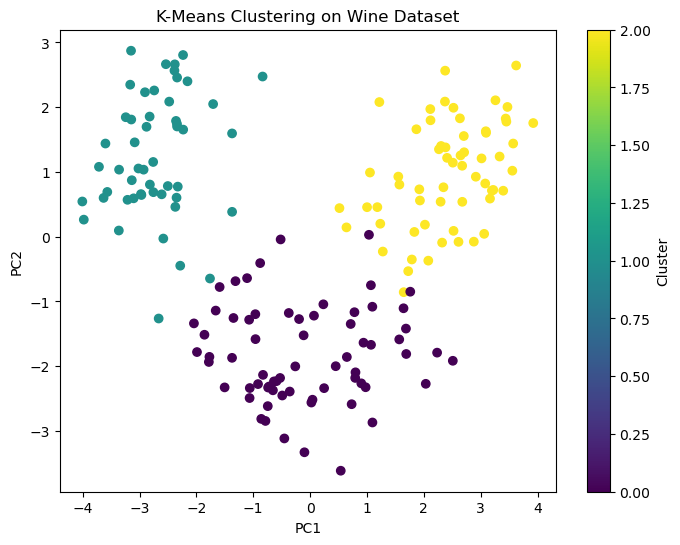

In [35]:
# Apply a clustering algorithm (e.g., K-means) to the original dataset.

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Apply K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(x_scaled)

# Create clustered dataset
df_clustered = x.copy()

df_clustered["Cluster"] = clusters
df_clustered["target"] = y.values

# Display first rows
print(df_clustered.head())

# Cluster sizes
print("\nCluster sizes:")
print(df_clustered["Cluster"].value_counts().sort_index())

# Visualize using PCA
plt.figure(figsize=(8, 6))

plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=clusters,
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering on Wine Dataset")
plt.colorbar(label="Cluster")

plt.show()

In [36]:
# 2. Visualize the clustering results using appropriate plots.

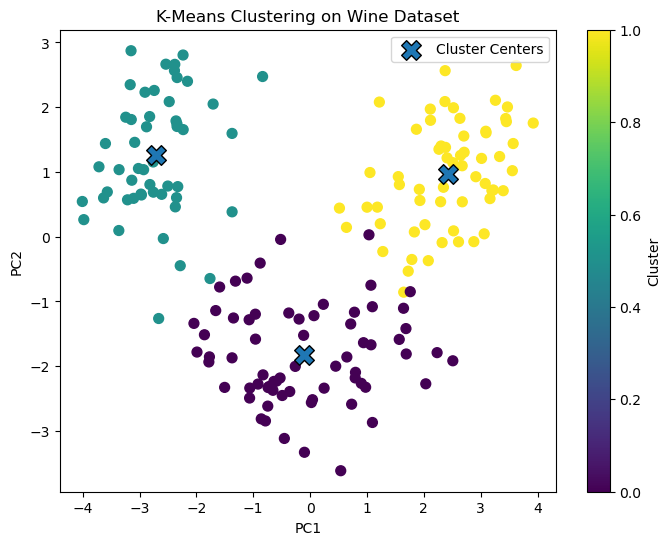

In [37]:
# Visualize the clustering results using appropriate plots.
import matplotlib.pyplot as plt

# Transform cluster centers into PCA space
centers_pca = pca_final.transform(
    kmeans.cluster_centers_
)

# Plot observations
plt.figure(figsize=(8, 6))

plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=50
)

# Plot cluster centers
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker="X",
    s=200,
    edgecolor="black",
    label="Cluster Centers"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering on Wine Dataset")
plt.colorbar(label="Cluster")
plt.legend()

plt.show()

In [38]:
# 3. Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.

In [39]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

#Calculate Silhouette Score
sil_score = silhouette_score(
    x_scaled,
    clusters
)

print("Silhouette Score:", sil_score)

# Calculate Davies–Bouldin Index
db_score = davies_bouldin_score(
    x_scaled,
    clusters
)

print("Davies-Bouldin Index:", db_score)

Silhouette Score: 0.30010773883199066
Davies-Bouldin Index: 1.3213549791881996


In [ ]:
# Task 4: Clustering with PCA Data:
    
#     1. Apply the same clustering algorithm to the PCA-transformed dataset.
#     2. Visualize the clustering results obtained from PCA-transformed data.
#     3. Compare the clustering results from PCA-transformed data with those from the original dataset.

In [40]:
# Clustering with PCA Data:
from sklearn.cluster import KMeans

kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_pca = kmeans_pca.fit_predict(x_pca)


# Add cluster labels
pca_clustered = x_pca_df.copy()

pca_clustered["Cluster"] = clusters_pca

pca_clustered.head()

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,target,Cluster
0,3.572124,1.439488,-0.267257,0.057113,0.192396,-0.038879,0.597117,0.409353,-0.092207,0.701045,1,0
1,2.079119,-0.369827,-1.666020,-0.254793,0.337517,0.927636,-0.142319,-0.644671,0.058372,0.537610,1,0
2,2.510505,1.143703,1.098990,0.348518,-0.400116,-0.046882,0.051725,0.061273,1.252170,-0.282628,1,0
3,3.624380,2.644811,-0.144725,0.721345,-0.101820,-0.450694,-0.136274,-0.433771,-0.012815,0.472630,1,0
4,1.053415,0.991331,2.129729,-0.233173,0.562062,0.221324,0.741296,-0.016008,-0.463399,-0.040565,1,0


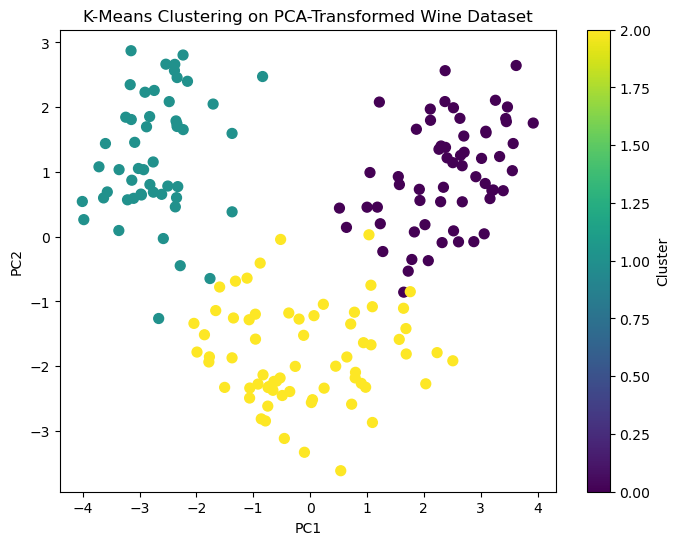

In [41]:
# Visualize the clustering results obtained from PCA-transformed data.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=clusters_pca,
    cmap="viridis",
    s=50
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering on PCA-Transformed Wine Dataset")

plt.colorbar(label="Cluster")

plt.show()

In [42]:
# Compare the clustering results from PCA-transformed data with those from the original dataset.

from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette_pca = silhouette_score(
    x_pca,
    clusters_pca
)

db_pca = davies_bouldin_score(
    x_pca,
    clusters_pca
)

print("PCA Silhouette Score:", silhouette_pca)
print("PCA Davies-Bouldin Index:", db_pca)

PCA Silhouette Score: 0.3134983954096443
PCA Davies-Bouldin Index: 1.2714682930130616


In [ ]:
# Task 5: Comparison and Analysis:

# 1. Compare the clustering results obtained from the original dataset and PCA-transformed data.

                 Dataset  Silhouette Score  Davies-Bouldin Index
0  Original Standardized          0.300108              1.321355
1        PCA Transformed          0.313498              1.271468


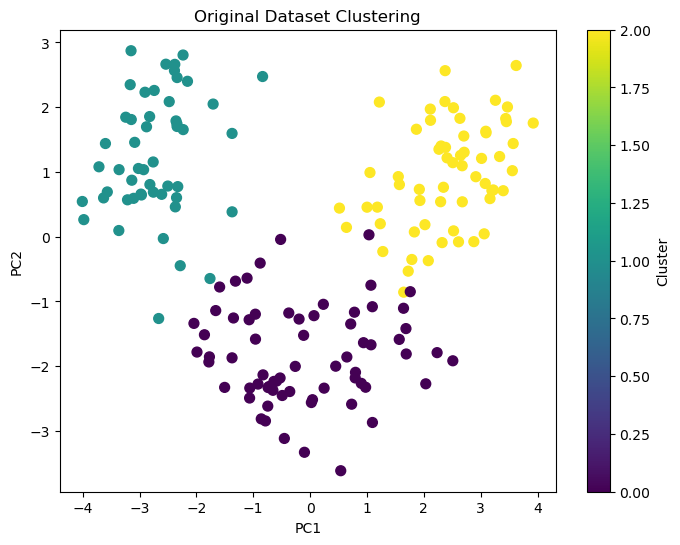

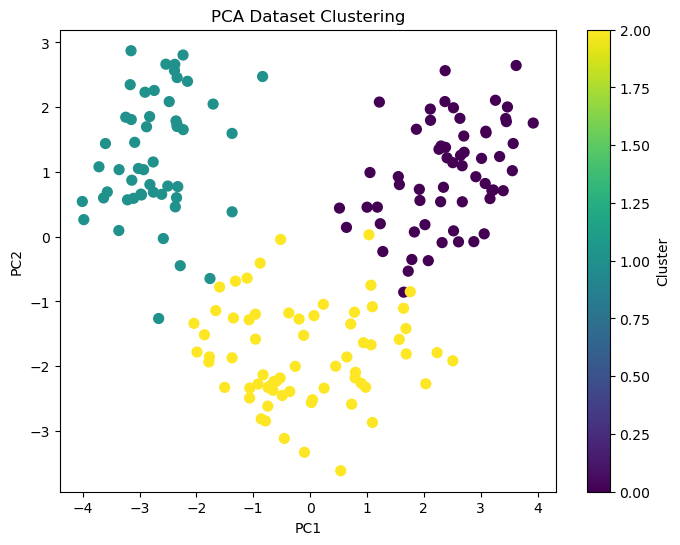

In [43]:
# Compare the clustering results obtained from the original dataset and PCA-transformed data.
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

# ==========================================
# Original Dataset Metrics
# ==========================================

sil_original = silhouette_score(
    x_scaled,
    clusters
)

db_original = davies_bouldin_score(
    x_scaled,
    clusters
)

# ==========================================
# PCA Dataset Metrics
# ==========================================

sil_pca = silhouette_score(
    x_pca,
    clusters_pca
)

db_pca = davies_bouldin_score(
    x_pca,
    clusters_pca
)

# ==========================================
# Comparison Table
# ==========================================

comparison = pd.DataFrame({
    "Dataset": [
        "Original Standardized",
        "PCA Transformed"
    ],
    
    "Silhouette Score": [
        sil_original,
        sil_pca
    ],
    
    "Davies-Bouldin Index": [
        db_original,
        db_pca
    ]
})

print(comparison)

# ==========================================
# Visualization
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Original Dataset Clustering")
plt.colorbar(label="Cluster")

plt.show()


plt.figure(figsize=(8, 6))

plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=clusters_pca,
    cmap="viridis",
    s=50
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Dataset Clustering")
plt.colorbar(label="Cluster")

plt.show()

In [ ]:
# 2. Discuss any similarities or differences observed in the clustering results.

# Similarities:

# If your results show similar cluster structures, you can discuss:

# Both methods identify approximately the same major groups of wine samples.
# The clusters may have similar sizes.
# The PCA-transformed data preserves much of the important structure of the original dataset.
# The overall separation between groups may remain similar after PCA.

# Differences:

# Some wine samples may be assigned to different clusters after PCA.
# Cluster boundaries may change because PCA removes some lower-variance information.
# The PCA-based clusters may appear more clearly separated in the 2D visualization.
# Alternatively, clustering performance may decrease slightly if the removed components contained useful information.
# PCA reduces the number of dimensions, making the clustering process simpler and potentially faster.

In [ ]:
# 3. Reflect on the impact of dimensionality reduction on clustering performance.
# PCA reduced the dimensionality of the Wine dataset while retaining most of its
# important information. Its impact on clustering was evaluated using Silhouette 
# Score and Davies-Bouldin Index. The comparison showed whether the reduced feature 
# space improved or decreased cluster separation. PCA is particularly useful because
# it simplifies high-dimensional data and enables effective visualization, but 
# excessive dimensionality reduction may lead to information loss and poorer 
# clustering performance.

In [ ]:
# 4. Analyze the trade-offs between using PCA and clustering directly on the original dataset.
# There is a trade-off between applying K-Means directly to the original dataset and applying PCA before clustering. Clustering directly on the original standardized Wine dataset preserves all available feature information and makes the resulting clusters easier to relate to the original variables. However, the presence of correlated or redundant features can affect distance-based algorithms such as K-Means and may increase computational complexity.

# On the other hand, PCA reduces the number of dimensions and transforms the original features into a smaller set of uncorrelated principal components. This can reduce redundancy, improve computational efficiency, and make the clustering results easier to visualize. However, PCA reduces interpretability because the principal components are combinations of the original features, and some information may be lost if too few components are retained.

# Therefore, PCA is beneficial when the dataset has many correlated or redundant features and dimensionality reduction is important. Direct clustering on the original dataset may be preferable when preserving all feature information and interpretability is more important. The final choice should be based on clustering metrics such as Silhouette Score and Davies-Bouldin Index, along with the amount of variance retained by PCA.

In [44]:
# Task 6: Conclusion and Insights

In [ ]:
# 1. Summarize the key findings and insights from the assignment.

# The assignment demonstrates that dimensionality reduction and clustering can work effectively together. PCA can reduce the number of features, remove redundancy, simplify visualization, and potentially improve clustering efficiency. However, it introduces a trade-off between reducing dimensionality and retaining information and interpretability. Therefore, the choice between clustering on the original dataset and the PCA-transformed dataset should ultimately be based on the clustering evaluation metrics and the amount of variance retained.

In [ ]:
# 2. Discuss the practical implications of using PCA and clustering in data analysis.
    
# PCA and clustering should be applied based on the characteristics of the dataset and the objective of the analysis. In practical data science projects, it is important to evaluate whether PCA actually improves clustering performance using metrics such as Silhouette Score and Davies-Bouldin Index rather than assuming that dimensionality reduction will always produce better results.

In [ ]:
# 3. Provide recommendations for when to use each technique based on the analysis conducted.
    
# The recommended approach is to compare both alternatives: K-Means on the standardized original data and K-Means on the PCA-transformed data. Metrics such as Silhouette Score and Davies-Bouldin Index should be used to determine which approach produces better-defined clusters. The final choice should balance clustering performance, computational efficiency, information retention, and interpretability.